In [3]:
import pandas as pd

df = pd.read_csv("../data/churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
# drop useless columns
df = df.drop([
    "CustomerID", "Count", "Country", "State", "City",
    "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Reason"
], axis=1)

In [7]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df = df.dropna()

In [8]:
y = df["Churn Value"]

In [9]:
X = df.drop(["Churn Label", "Churn Value"], axis=1)

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
X.head()
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Tenure Months                           7032 non-null   int64  
 1   Monthly Charges                         7032 non-null   float64
 2   Total Charges                           7032 non-null   float64
 3   Churn Score                             7032 non-null   int64  
 4   CLTV                                    7032 non-null   int64  
 5   Gender_Male                             7032 non-null   bool   
 6   Senior Citizen_Yes                      7032 non-null   bool   
 7   Partner_Yes                             7032 non-null   bool   
 8   Dependents_Yes                          7032 non-null   bool   
 9   Phone Service_Yes                       7032 non-null   bool   
 10  Multiple Lines_No phone service         7032 non-null   bool   
 

In [12]:
X = X.drop(["Churn Score", "CLTV"], axis=1)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8130774697938877
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1012
           1       0.71      0.57      0.63       395

    accuracy                           0.81      1407
   macro avg       0.78      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407



In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.7910447761194029
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1012
           1       0.67      0.49      0.57       395

    accuracy                           0.79      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [19]:
!pip install seaborn matplotlib

In [20]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


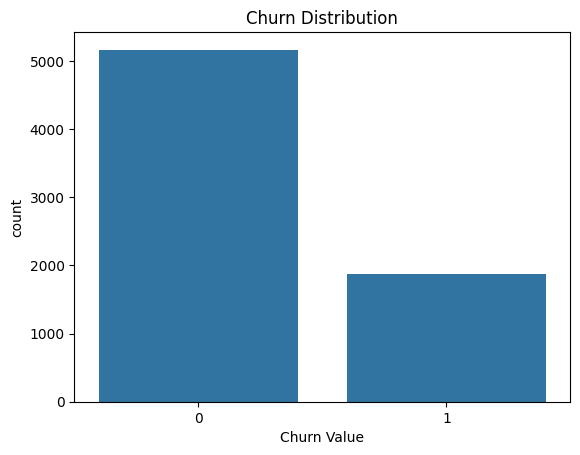

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Churn Distribution")
plt.savefig("../report/Churn_Distribution.png")
plt.show()

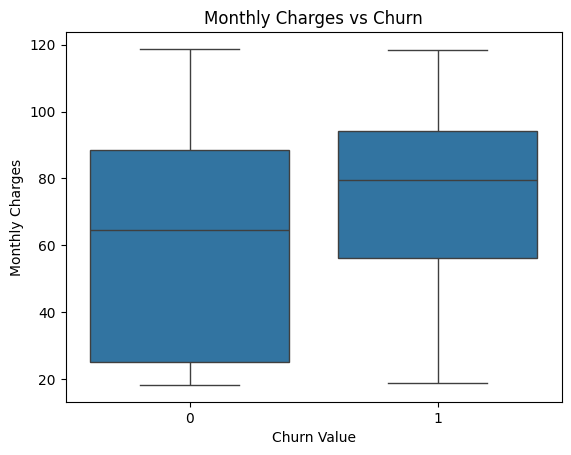

In [25]:
sns.boxplot(x=y, y=df["Monthly Charges"])
plt.title("Monthly Charges vs Churn")
plt.savefig("../report/monthly_charges_vs_churn.png")
plt.show()


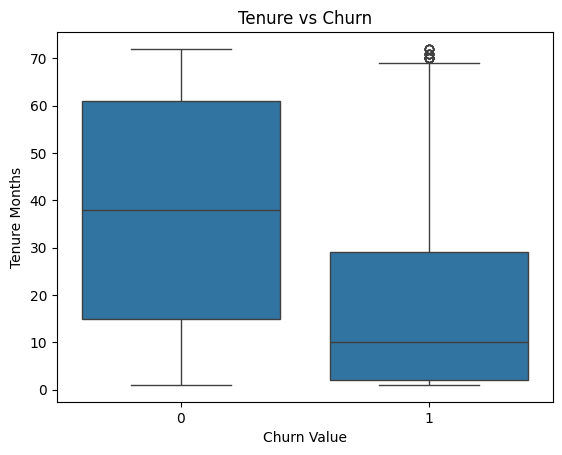

In [28]:
sns.boxplot(x=y, y=df["Tenure Months"])
plt.title("Tenure vs Churn")
plt.savefig("../report/Tenure-vs_Churn.png")
plt.show()

In [30]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [31]:
import pickle

pickle.dump(rf, open("../app/model.pkl", "wb"))

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
import pickle

pickle.dump(rf, open("../app/model.pkl", "wb"))


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
import pickle

pickle.dump(model, open("../app/model.pkl", "wb"))